<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/lecture_notes/notebooks/11_StructuralBreaks_and_Intervention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 11 실습: 구조변화, 이상치, 개입분석
**Notebook:** `11_StructuralBreaks_and_Intervention.ipynb`

## 실습 목표 (Learning Objectives)
이 실습에서는 다음을 수행합니다.

1. 시계열에서 이상치(Outlier), 구조변화(Structural Break), 개입(Intervention)의 차이를 직관적으로 이해합니다.
2. 추세와 계절성을 가진 월별 데이터를 생성하고, 특정 시점에 pulse shock와 step change를 주입합니다.
3. 시각화와 rolling statistics를 통해 구조적 변화의 징후를 탐색합니다.
4. 간단한 회귀 기반 구조변화 진단과 CUSUM 개념을 확인합니다.
5. pulse dummy와 step dummy를 만들어 ARIMAX/SARIMAX 형태로 개입분석을 수행합니다.
6. 개입 변수 포함 전후의 AIC, 잔차, 계수 유의성을 비교합니다.
7. 구조변화가 예측과 해석에 어떤 영향을 주는지 설명할 수 있습니다.

---

## 왜 이 실습이 중요한가?
전통적인 시계열 모형은 대체로 “과거의 데이터 생성 메커니즘이 미래에도 크게 바뀌지 않는다”는 전제 위에서 작동합니다.  
하지만 현실에서는 팬데믹, 정책 변화, 파업, 규제 변화, 프로모션, 시스템 장애와 같은 사건들이 이 전제를 깨뜨립니다.

이때 중요한 것은 모든 비정상적 움직임을 단순 노이즈로 보는 것이 아니라,  
**일시적 충격인지**, **장기 수준 변화인지**, **모형에 반영해야 할 개입인지**를 구분하는 것입니다.

이번 실습의 핵심은 단순히 더미 변수를 넣어보는 것이 아니라,  
**“이 시점의 변화는 일시적인가, 영구적인가, 또는 구조 자체가 바뀐 것인가?”**를 데이터와 모형을 함께 통해 해석하는 데 있습니다.


In [1]:
# ============================================
# 1. 필수 라이브러리 불러오기
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from IPython.display import display


## 1. 시각화 기본 설정
이번 버전도 Colab 호환성을 위해 **그래프 텍스트는 영어**로 출력합니다.  
마크다운 셀과 코드 주석은 한글로 유지합니다.


In [2]:
# ============================================
# 2. 시각화 기본 설정
# ============================================

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.unicode_minus"] = False


## 2. 실습용 월별 시계열 데이터 생성
이번 실습에서는 교육 목적상 **구조가 명확한 synthetic monthly sales data**를 사용합니다.

데이터 구조는 다음과 같습니다.

- 완만한 상승 추세
- 12개월 계절성
- 일반적인 랜덤 노이즈
- 특정 시점의 단발성 pulse shock
- 특정 시점 이후의 영구적 수준 변화 step change

이렇게 하면 이상치와 구조변화를 동시에 실습하기에 적합합니다.


In [3]:
# ============================================
# 3. Synthetic monthly sales series 생성
# ============================================

np.random.seed(42)

dates = pd.date_range(start="2015-01-31", periods=120, freq="M")
t = np.arange(len(dates))

trend = 100 + 0.4 * t

monthly_factors = np.array([0.95, 0.96, 0.98, 1.00, 1.03, 1.06, 1.08, 1.07, 1.04, 1.01, 0.99, 1.10])
seasonality = np.tile(monthly_factors, len(dates) // 12)

noise = np.random.normal(0, 2.5, len(dates))

sales = trend * seasonality + noise

pulse_date = pd.Timestamp("2020-04-30")
step_date = pd.Timestamp("2021-01-31")
outlier_date = pd.Timestamp("2018-07-31")

pulse_idx = np.where(dates == pulse_date)[0][0]
step_idx = np.where(dates == step_date)[0][0]
outlier_idx = np.where(dates == outlier_date)[0][0]

sales[pulse_idx] = sales[pulse_idx] - 22
sales[step_idx:] = sales[step_idx:] + 10
sales[outlier_idx] = sales[outlier_idx] + 15

df = pd.DataFrame({"sales": sales}, index=dates)
display(df.head())


,sales
2015-01-31,96.241785
2015-02-28,96.038339
2015-03-31,100.403221
2015-04-30,105.007575
2015-05-31,104.062617


## 3. 개입 더미 변수 만들기
개입분석에서는 보통 다음과 같은 더미를 사용합니다.

- **Pulse dummy**: 사건이 발생한 한 시점만 1
- **Step dummy**: 사건 발생 이후 계속 1
- **Outlier dummy**: 특정 이상치 시점만 1

이 더미들은 이후 ARIMAX/SARIMAX의 `exog`로 사용됩니다.


In [4]:
# ============================================
# 4. 개입 더미 생성
# ============================================

df["pulse_dummy"] = 0
df.loc[pulse_date, "pulse_dummy"] = 1

df["step_dummy"] = 0
df.loc[df.index >= step_date, "step_dummy"] = 1

df["outlier_dummy"] = 0
df.loc[outlier_date, "outlier_dummy"] = 1

display(df.loc["2018":"2021"].head(20))


,sales,pulse_dummy,step_dummy,outlier_dummy
2018-01-31,109.202159,0,0,0
2018-02-28,105.308825,0,0,0
2018-03-31,109.575535,0,0,0
2018-04-30,116.092153,0,0,0
2018-05-31,121.326166,0,0,0
2018-06-30,123.812421,0,0,0
2018-07-31,140.854879,0,0,1
2018-08-31,124.651241,0,0,0
2018-09-30,118.607695,0,0,0
2018-10-31,117.380389,0,0,0


## 4. 원시 시계열 플롯
이제 원시 시계열을 그리고, 개입 시점을 수직선으로 표시해 보겠습니다.

관찰 포인트는 다음과 같습니다.

- 전반적인 추세가 있는가?
- 계절성이 반복되는가?
- 특정 시점에 급락 또는 급등이 있는가?
- 어떤 시점 이후 평균 수준이 달라지는가?


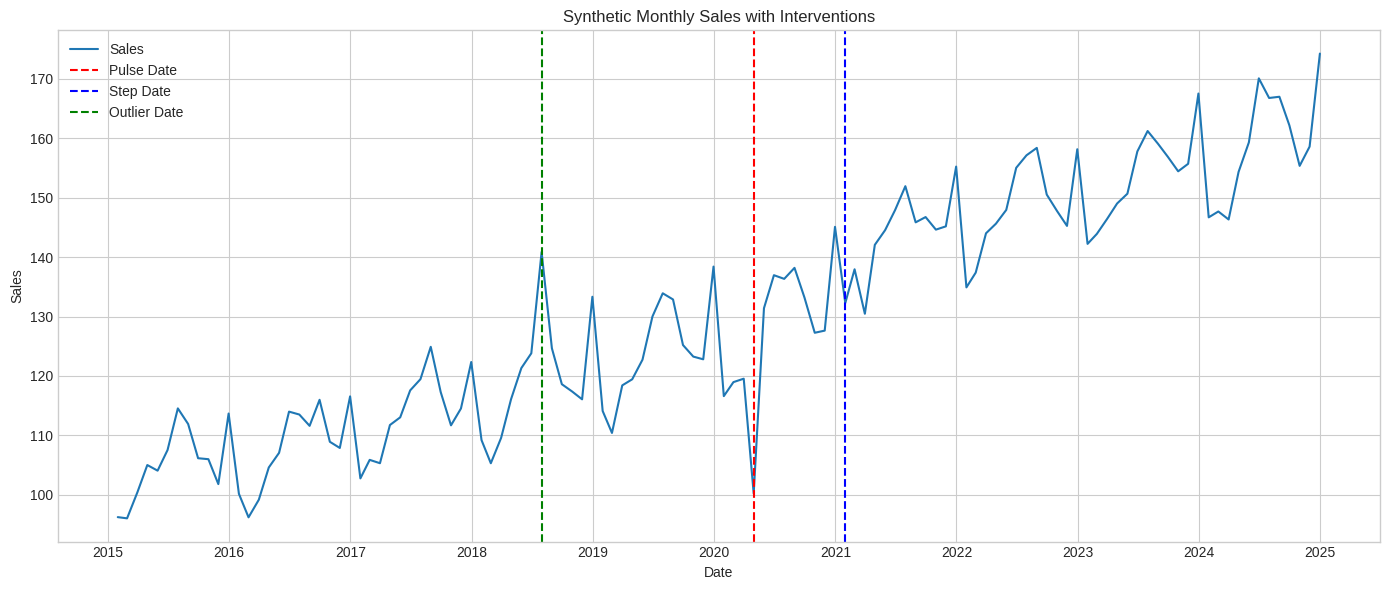

In [5]:
# ============================================
# 5. 원시 시계열 플롯
# ============================================

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["sales"], linewidth=1.5, label="Sales")
plt.axvline(pulse_date, color="red", linestyle="--", label="Pulse Date")
plt.axvline(step_date, color="blue", linestyle="--", label="Step Date")
plt.axvline(outlier_date, color="green", linestyle="--", label="Outlier Date")

plt.title("Synthetic Monthly Sales with Interventions")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Rolling statistics로 구조변화의 징후 보기
구조변화가 있으면 rolling mean과 rolling std에서 눈에 띄는 변화가 나타날 수 있습니다.  
특히 평균 수준이 바뀌는 step change는 rolling mean에서 더 잘 보이는 경우가 많습니다.


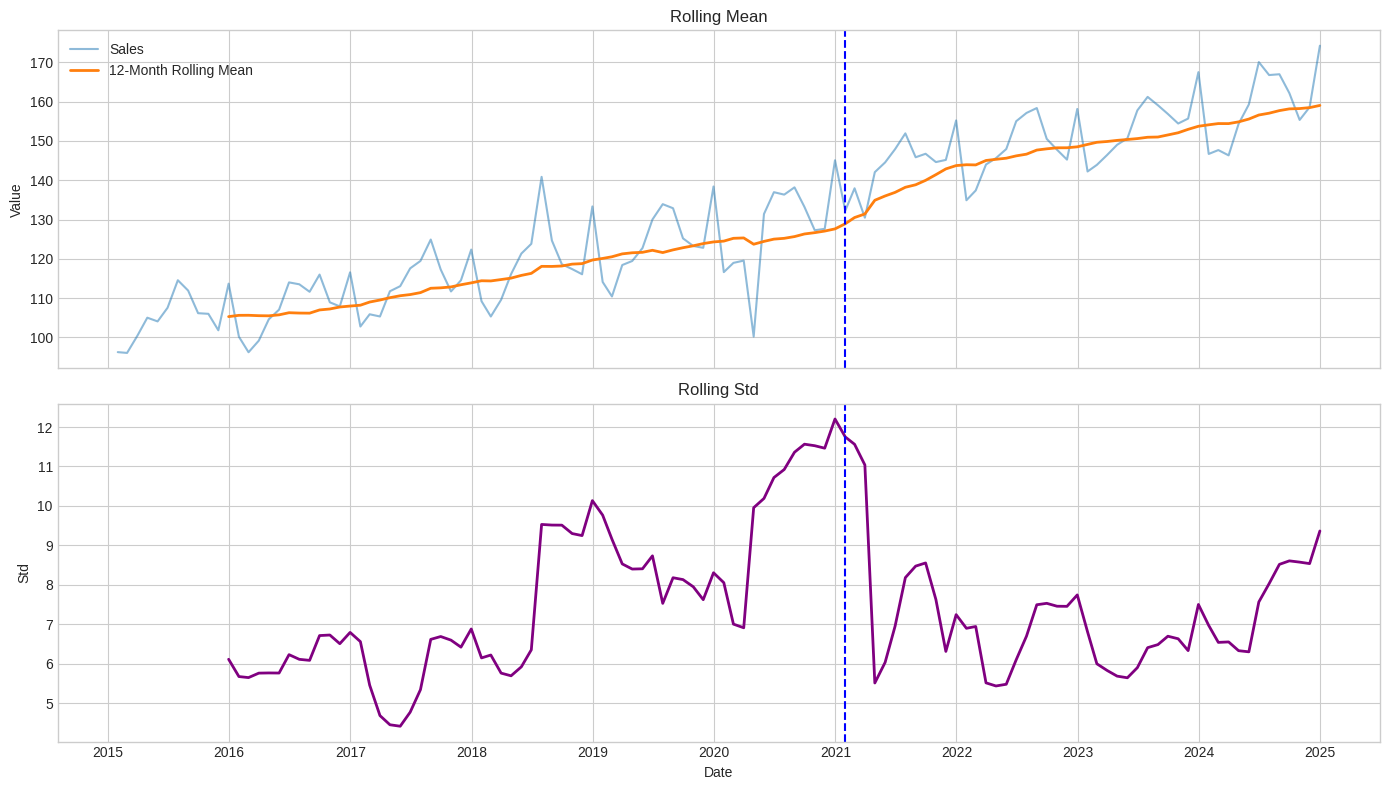

In [6]:
# ============================================
# 6. Rolling mean / std
# ============================================

df["roll_mean_12"] = df["sales"].rolling(window=12).mean()
df["roll_std_12"] = df["sales"].rolling(window=12).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df["sales"], label="Sales", alpha=0.5)
axes[0].plot(df.index, df["roll_mean_12"], label="12-Month Rolling Mean", linewidth=2)
axes[0].axvline(step_date, color="blue", linestyle="--")
axes[0].set_title("Rolling Mean")
axes[0].set_ylabel("Value")
axes[0].legend()

axes[1].plot(df.index, df["roll_std_12"], color="purple", linewidth=2)
axes[1].axvline(step_date, color="blue", linestyle="--")
axes[1].set_title("Rolling Std")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Std")

plt.tight_layout()
plt.show()


## 6. STL 분해로 구조 파악
이상치와 개입이 있더라도, 먼저 시계열의 기본 구조(Trend / Seasonal / Residual)를 보는 것이 유용합니다.  
여기서는 STL 분해를 사용합니다.


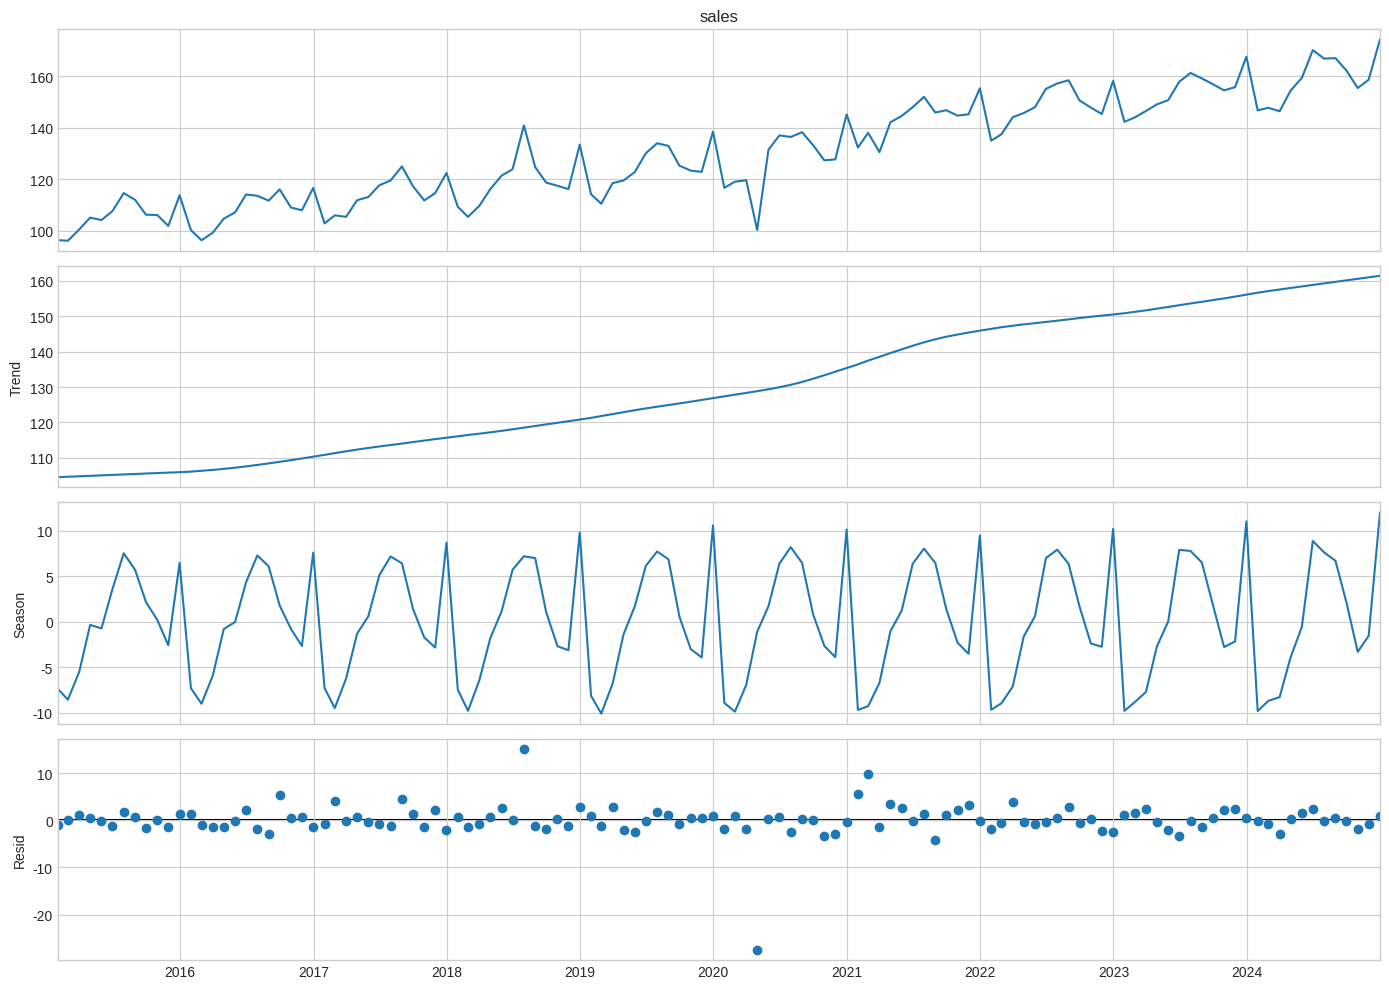

In [7]:
# ============================================
# 7. STL decomposition
# ============================================

from statsmodels.tsa.seasonal import STL

stl = STL(df["sales"], period=12, robust=True)
stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()


## 7. 이상치 후보 탐색
이상치는 구조변화와 다릅니다.  
이상치는 특정 시점의 비정상적 값일 수 있지만, 구조변화는 그 이후 데이터 생성 구조가 바뀌는 현상입니다.

여기서는 간단히 STL residual의 z-score를 사용해 이상치 후보를 확인합니다.


In [8]:
# ============================================
# 8. STL residual 기반 이상치 후보 탐색
# ============================================

resid = stl_result.resid.dropna()
z_score = (resid - resid.mean()) / resid.std()

outlier_candidates = pd.DataFrame({
    "residual": resid,
    "z_score": z_score
})

outlier_candidates = outlier_candidates.loc[np.abs(outlier_candidates["z_score"]) > 2.5]
display(outlier_candidates)


,residual,z_score
2018-07-31,15.136949,4.285602
2020-04-30,-27.513746,-7.838780
2021-02-28,9.753503,2.755242


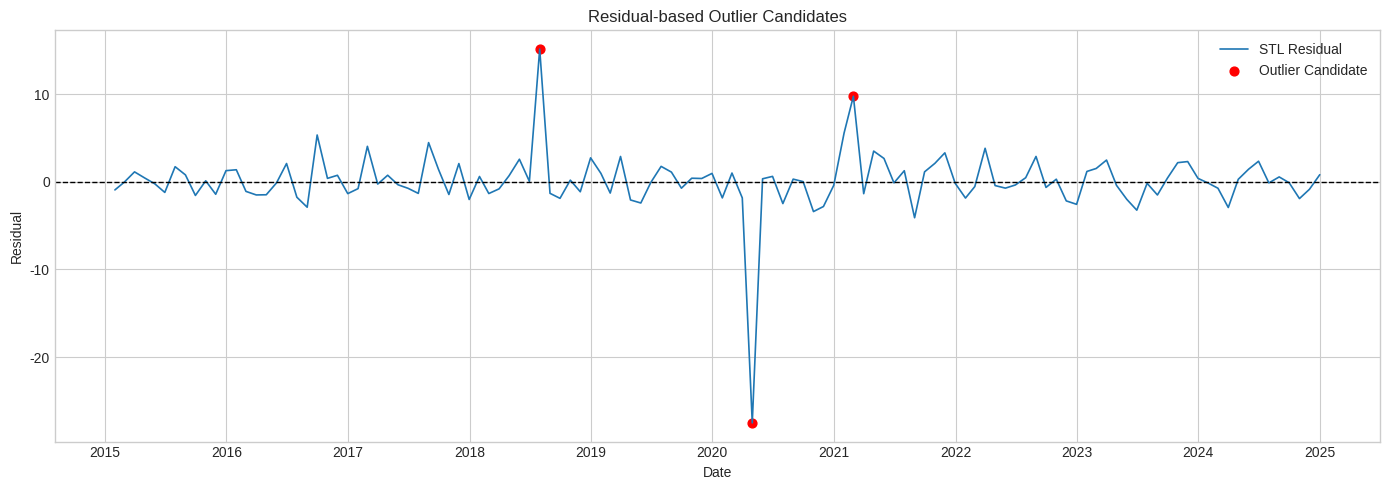

In [9]:
# ============================================
# 9. 이상치 후보 시각화
# ============================================

plt.figure(figsize=(14, 5))
plt.plot(resid.index, resid, label="STL Residual", linewidth=1.2)

if len(outlier_candidates) > 0:
    plt.scatter(
        outlier_candidates.index,
        outlier_candidates["residual"],
        color="red",
        s=40,
        label="Outlier Candidate"
    )

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Residual-based Outlier Candidates")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.tight_layout()
plt.show()


## 8. 간단한 회귀 기반 구조변화 진단
구조변화를 직관적으로 보기 위해, 추세와 계절성을 설명하는 OLS 회귀를 먼저 적합하고 residual stability를 점검해 볼 수 있습니다.

여기서는
- 시간 추세
- 월 더미(계절성)

를 포함한 간단한 회귀를 적합한 뒤, CUSUM 계열 검정의 아이디어를 적용합니다.


In [10]:
# ============================================
# 10. OLS 설계행렬 만들기
# ============================================

import statsmodels.api as sm

ols_df = df.copy()
ols_df["trend"] = np.arange(len(ols_df))
ols_df["month"] = ols_df.index.month.astype("category")

X = pd.get_dummies(ols_df[["trend", "month"]], columns=["month"], drop_first=True, dtype=float)
X = sm.add_constant(X)

ols_model = sm.OLS(ols_df["sales"], X).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     187.1
Date:                Sun, 15 Mar 2026   Prob (F-statistic):           5.95e-66
Time:                        02:38:42   Log-Likelihood:                -345.60
No. Observations:                 120   AIC:                             717.2
Df Residuals:                     107   BIC:                             753.4
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         90.8038      1.584     57.312      0.0

In [11]:
# ============================================
# 11. CUSUM 아이디어 확인
# ============================================
# breaks_cusumolsresid는 OLS 잔차에 기반한 안정성 검정의 예입니다.
# p-value가 작으면 구조 안정성을 의심할 수 있습니다.
# ============================================

from statsmodels.stats.diagnostic import breaks_cusumolsresid

cusum_stat, cusum_pvalue, crit = breaks_cusumolsresid(ols_model.resid, ddof=int(ols_model.df_model))

print("CUSUM Statistic:", round(cusum_stat, 4))
print("CUSUM p-value  :", round(cusum_pvalue, 6))
print("Critical values:", crit)


CUSUM Statistic: 1.6754
CUSUM p-value  : 0.007294
Critical values: [(1, 1.63), (5, 1.36), (10, 1.22)]


## 9. 개입분석용 학습/테스트 분할
이제 개입 더미를 포함한 예측 모형을 만들기 위해 데이터를 학습/테스트 구간으로 나눕니다.  
마지막 24개월을 테스트 구간으로 두겠습니다.


In [12]:
# ============================================
# 12. Train / Test split
# ============================================

test_size = 24

train = df.iloc[:-test_size].copy()
test = df.iloc[-test_size:].copy()

print("Train length:", len(train))
print("Test length :", len(test))

display(pd.DataFrame({
    "Train_End": [train.index.max()],
    "Test_Start": [test.index.min()],
    "Test_End": [test.index.max()]
}))


Train length: 96
Test length : 24


,Train_End,Test_Start,Test_End
0,2022-12-31,2023-01-31,2024-12-31


## 10. 개입 변수를 넣지 않은 기준 모형
먼저 계절성과 자기상관만 반영하는 기준 SARIMAX 모형을 적합합니다.  
여기서는 간단한 예시로 `(1,1,1) × (1,0,1,12)`를 사용합니다.


In [13]:
# ============================================
# 13. 기준 SARIMAX 모형 (개입 없음)
# ============================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

base_model = SARIMAX(
    train["sales"],
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(base_model.summary())


                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                   96
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -248.450
Date:                            Sun, 15 Mar 2026   AIC                            506.901
Time:                                    02:38:43   BIC                            518.873
Sample:                                01-31-2015   HQIC                           511.704
                                     - 12-31-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0340      0.125     -0.271      0.786      -0.280       0.212
ma.L1         -0.7367      0.111   

## 11. 개입 변수를 포함한 ARIMAX/SARIMAX 모형
이제 pulse, step, outlier 더미를 외생변수(exog)로 포함합니다.

이 모형은 다음 질문에 답하려고 합니다.

- pulse shock는 일시적으로 얼마나 큰 영향을 주었는가?
- step change는 영구적으로 얼마나 수준을 바꾸었는가?
- outlier dummy는 특정 이상치를 설명하는가?


In [14]:
# ============================================
# 14. 개입 변수 포함 SARIMAX
# ============================================

exog_cols = ["pulse_dummy", "step_dummy", "outlier_dummy"]

int_model = SARIMAX(
    train["sales"],
    exog=train[exog_cols],
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(int_model.summary())


                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                   96
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -197.209
Date:                            Sun, 15 Mar 2026   AIC                            410.419
Time:                                    02:38:44   BIC                            429.574
Sample:                                01-31-2015   HQIC                           418.104
                                     - 12-31-2022                                         
Covariance Type:                              opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
pulse_dummy     -26.7427     10.249     -2.609      0.009     -46.830      -6.655
step_dummy        8.6503  

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 12. 개입 모형 전후 비교
여기서는 다음을 비교합니다.

- AIC
- 잔차 분산
- 개입 변수 계수

개입 변수를 넣었을 때 AIC가 낮아지고 잔차 구조가 더 안정적이면,  
해당 개입이 실제로 시계열을 설명하는 데 도움이 되었다고 볼 수 있습니다.


In [15]:
# ============================================
# 15. AIC와 잔차 분산 비교
# ============================================

comparison_df = pd.DataFrame({
    "Model": ["Baseline SARIMAX", "Intervention SARIMAX"],
    "AIC": [base_model.aic, int_model.aic],
    "Residual_Variance": [np.var(base_model.resid.dropna()), np.var(int_model.resid.dropna())]
})

display(comparison_df)


,Model,AIC,Residual_Variance
0,Baseline SARIMAX,506.900725,158.930338
1,Intervention SARIMAX,410.418727,145.056647


In [16]:
# ============================================
# 16. 개입 변수 계수만 정리
# ============================================

coef_table = pd.DataFrame({
    "coef": int_model.params,
    "pvalue": int_model.pvalues
})

coef_table = coef_table.loc[[idx for idx in coef_table.index if idx in exog_cols]]
display(coef_table)


,coef,pvalue
pulse_dummy,-26.742677,9.071437e-03
step_dummy,8.650257,6.589407e-19
outlier_dummy,14.451179,1.261763e-03


## 13. 잔차 진단 비교
좋은 개입 모형이라면 개입 시점 주변의 큰 오차를 줄이고, 잔차의 자기상관을 더 작게 만들어야 합니다.


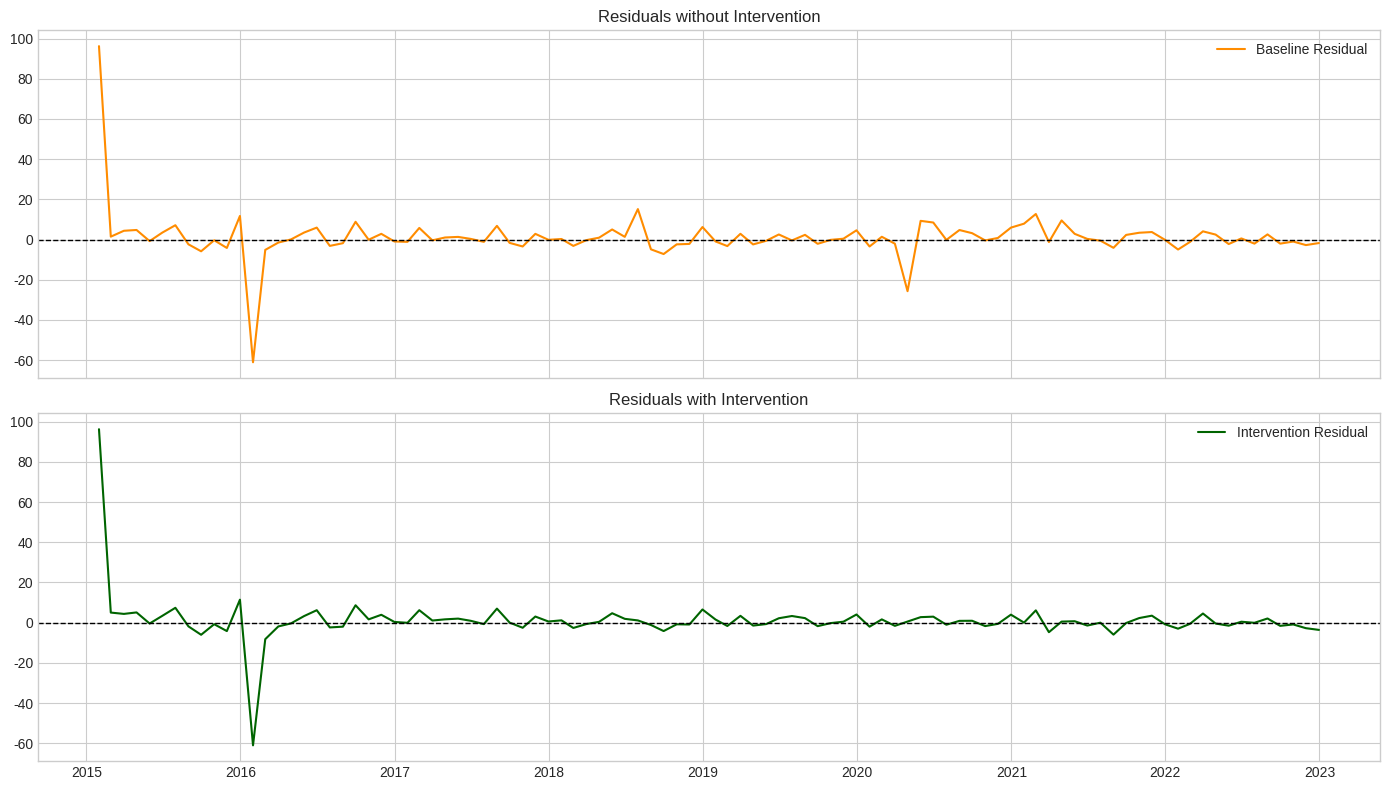

In [17]:
# ============================================
# 17. 잔차 비교 플롯
# ============================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(base_model.resid, label="Baseline Residual", color="darkorange")
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Residuals without Intervention")
axes[0].legend()

axes[1].plot(int_model.resid, label="Intervention Residual", color="darkgreen")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Residuals with Intervention")
axes[1].legend()

plt.tight_layout()
plt.show()


In [18]:
# ============================================
# 18. Ljung-Box 검정 비교
# ============================================

from statsmodels.stats.diagnostic import acorr_ljungbox

lb_base = acorr_ljungbox(base_model.resid.dropna(), lags=[12], return_df=True)
lb_int = acorr_ljungbox(int_model.resid.dropna(), lags=[12], return_df=True)

print("Baseline model Ljung-Box:")
display(lb_base)

print("Intervention model Ljung-Box:")
display(lb_int)


Baseline model Ljung-Box:


,lb_stat,lb_pvalue
12,21.383039,0.045045


Intervention model Ljung-Box:


,lb_stat,lb_pvalue
12,23.533716,0.023522


## 14. 테스트 구간 예측 비교
이제 기준 모형과 개입 모형이 테스트 구간을 어떻게 예측하는지 비교합니다.

개입 모형은 테스트 구간의 exogenous dummy도 함께 입력해야 합니다.


In [19]:
# ============================================
# 19. 테스트 구간 예측
# ============================================

base_forecast = base_model.get_forecast(steps=len(test)).predicted_mean

int_forecast = int_model.get_forecast(
    steps=len(test),
    exog=test[exog_cols]
).predicted_mean

forecast_df = pd.DataFrame({
    "Actual": test["sales"],
    "Baseline": base_forecast,
    "Intervention": int_forecast
})

display(forecast_df.head())


,Actual,Baseline,Intervention
2023-01-31,142.220301,143.224163,142.353264
2023-02-28,143.900638,143.483233,142.560260
2023-03-31,146.428784,145.802335,145.095979
2023-04-30,149.013532,148.022921,151.194746
2023-05-31,150.661573,153.849630,154.042187


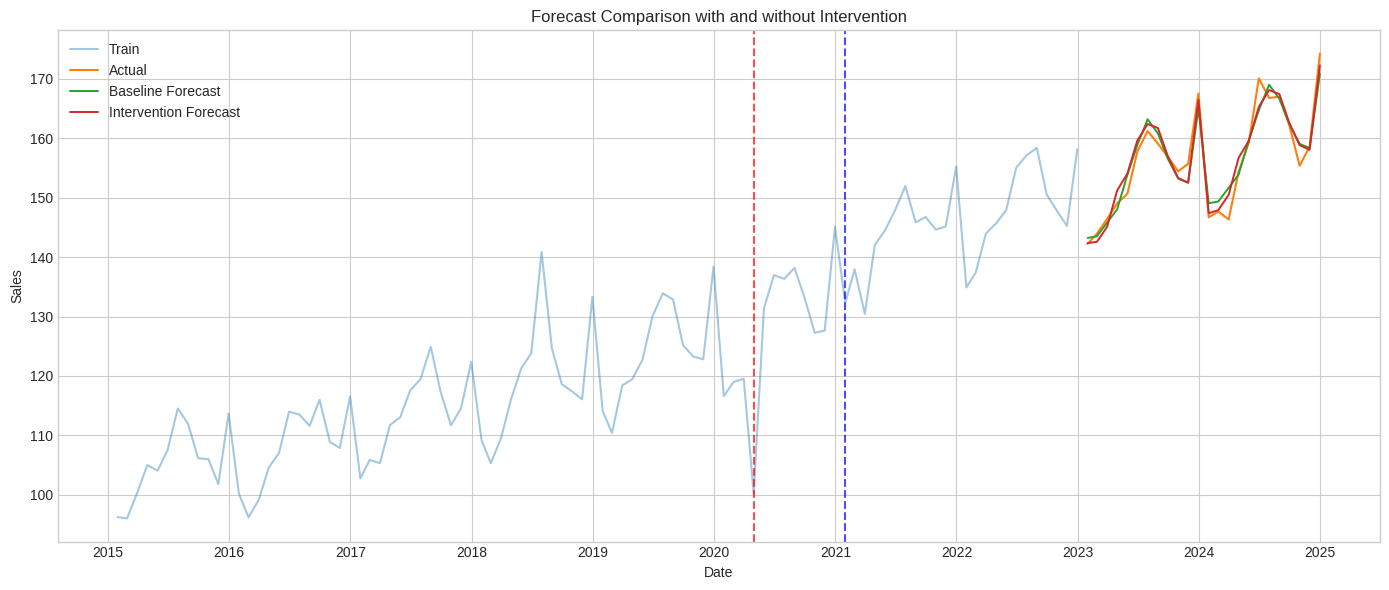

In [20]:
# ============================================
# 20. 실제값 vs 예측값 플롯
# ============================================

plt.figure(figsize=(14, 6))
plt.plot(train.index, train["sales"], label="Train", alpha=0.4)
plt.plot(test.index, test["sales"], label="Actual", linewidth=1.5)
plt.plot(base_forecast.index, base_forecast, label="Baseline Forecast", linewidth=1.4)
plt.plot(int_forecast.index, int_forecast, label="Intervention Forecast", linewidth=1.4)

plt.axvline(step_date, color="blue", linestyle="--", alpha=0.7)
plt.axvline(pulse_date, color="red", linestyle="--", alpha=0.7)

plt.title("Forecast Comparison with and without Intervention")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()


## 15. 예측 오차 비교
개입분석의 가치는 단순히 설명력 향상뿐 아니라,  
개입 시점을 모형에 명시적으로 반영함으로써 예측과 해석을 함께 개선할 수 있다는 데 있습니다.


In [21]:
# ============================================
# 21. 평가 지표 계산
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_forecast(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return pd.DataFrame({
        "Model": [model_name],
        "MAE": [mae],
        "RMSE": [rmse]
    })

eval_base = evaluate_forecast(test["sales"], base_forecast, "Baseline SARIMAX")
eval_int = evaluate_forecast(test["sales"], int_forecast, "Intervention SARIMAX")

eval_df = pd.concat([eval_base, eval_int], ignore_index=True)
display(eval_df.sort_values("RMSE"))


,Model,MAE,RMSE
1,Intervention SARIMAX,1.673240,2.127781
0,Baseline SARIMAX,1.832088,2.373968


## 16. 해석 포인트
이번 장의 결과를 해석할 때는 다음 질문을 던져야 합니다.

- pulse 더미 계수는 일시적 충격의 크기를 잘 반영하는가?
- step 더미 계수는 영구적 수준 변화를 설명하는가?
- 개입 모형이 AIC와 잔차 구조를 개선했는가?
- baseline 모형이 설명하지 못한 급격한 변화가 개입 변수로 설명되는가?

즉, 개입분석의 핵심은 “설명되지 않던 변화를 설명 가능한 사건으로 바꾸는 것”에 있습니다.


## 17. 자주 발생하는 실수 (Common Mistakes)
이번 장에서 특히 자주 발생하는 실수는 다음과 같습니다.

1. **이상치와 구조변화를 같은 것으로 보는 실수**  
   이상치는 특정 시점의 비정상 값일 수 있지만, 구조변화는 이후의 평균·추세·분산 자체가 바뀌는 현상입니다.

2. **pulse와 step 더미를 혼동하는 실수**  
   한 시점만 영향을 주는 충격인지, 이후 수준을 계속 바꾸는 충격인지 구분해야 합니다.

3. **설명력이 높아졌다고 바로 인과효과로 단정하는 실수**  
   개입분석은 해석 도구이지만, 내생성이나 동시결정 문제가 있으면 인과적 단정은 조심해야 합니다.

4. **더미를 지나치게 많이 넣는 실수**  
   모든 튀는 값을 더미로 설명하려 하면 과적합과 데이터 스누핑 문제가 생길 수 있습니다.


## 18. 실습 정리
이번 실습에서 확인한 핵심은 다음과 같습니다.

- 시계열의 비정상적 움직임은 이상치, 일시적 충격, 구조변화로 구분해 볼 수 있다.
- pulse dummy는 단발성 충격을, step dummy는 영구적 수준 변화를 표현한다.
- 개입분석은 ARIMAX/SARIMAX의 exogenous variable 형태로 구현할 수 있다.
- 구조변화를 무시하면 잔차가 커지고 예측이 왜곡될 수 있다.
- 개입 모형은 예측뿐 아니라 사건의 해석 가능성을 높여 준다.


## 19. 연습문제 (Exercises)

1. pulse shock의 크기를 더 크게 또는 더 작게 바꾸어 개입 변수 계수가 어떻게 달라지는지 비교하시오.

2. step change 시점을 2021-01 대신 다른 날짜로 바꾸고 AIC와 예측 성능 변화를 비교하시오.

3. outlier dummy를 제거한 모형과 포함한 모형의 잔차 차이를 비교하시오.

4. baseline SARIMAX와 intervention SARIMAX의 Ljung-Box 결과를 비교하여 어느 쪽이 더 안정적인지 설명하시오.

5. 실제 비즈니스 데이터에서 프로모션, 팬데믹, 정책 변경을 pulse 또는 step 중 어느 유형으로 볼 수 있을지 예를 들어 설명하시오.
